# Machine Learning CA1 – Student Outcome Classification

---

| | |
|---|---|
| **Programme** | BSc (Hons) in Computing – Artificial Intelligence |
| **Module** | Machine Learning for AI |
| **Lecturer** | David McQuaid |
| **Assignment** | ML_CA1_V7 |
| **Submission Deadline** | 19/04/2026 at 11:59 pm |

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis)
3. [Data Preparation](#3-data-preparation)
4. [Classification Algorithms](#4-classification-algorithms)
5. [Final Classification and Accuracy Analysis](#5-final-classification)
6. [Conclusions](#6-conclusions)
7. [References](#7-references)


---
## 1. Introduction

This notebook covers the full ML pipeline for the CCT College Dublin Machine Learning CA1 assignment. The dataset (`student_dataV3.csv`) has demographic, socio-economic, and academic data for students at a Portuguese higher education institution. The goal is to classify each student as **Dropout**, **Enrolled**, or **Graduate** by the end of their normal course duration.

The work is split into four main parts:

- **Section 2** — EDA: getting to know the data, spotting distributions, relationships, and any quality issues (spoiler: there are a few).
- **Section 3** — Data Preparation: cleaning up the mess found in EDA and getting everything ready for modelling.
- **Section 4** — Classification Algorithms: building and tuning at least two classifiers, comparing results.
- **Section 5** — Final Classification: running the best model on the test set and analysing how well it generalises.

The dataset was originally published by Realinho et al. (2022) and has been widely used in educational data mining research.


---
## 2. Exploratory Data Analysis

### 2.1 Loading Libraries and the Dataset

Before doing anything else, let's load the data and take a look at what we're working with. We'll load it raw — no preprocessing yetm so we can see any data quality issues as they actually are.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Load raw data (keep as-is to expose dirty values)
df_raw = pd.read_csv('student_dataV3.csv')

# Normalise Target column: fix case/abbreviation inconsistencies
target_map = {
    'Grad': 'Graduate', 'graduate': 'Graduate',
    'Drop': 'Dropout',  'dropout': 'Dropout',
    'enrolled': 'Enrolled'
}
df_raw['Target'] = df_raw['Target'].replace(target_map)

print(f"Dataset shape: {df_raw.shape}")
print(f"Target classes after normalisation: {sorted(df_raw['Target'].unique())}")
df_raw.head()


Dataset shape: (4424, 37)
Target classes after normalisation: ['Dropout', 'Enrolled', 'Graduate']


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171.0,1,1,122.0,1,19,12.0,...,0,0.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254.0,1,1,160.0,1,1,3.0,...,0,6.0,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070.0,1,1,122.0,1,37,37.0,...,0,6.0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773.0,1,1,122.0,1,38,37.0,...,0,6.0,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014.0,0,1,100.0,1,37,38.0,...,0,6.0,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 2.2 Dataset Overview and Data Types


In [2]:
print("=== Data Types ===")
print(df_raw.dtypes)


=== Data Types ===
Marital status                                     object
Application mode                                    int64
Application order                                   int64
Course                                            float64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                            float64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                          object
Educational special needs                           int64
Debtor                                            float64
Tuition fees up to date                            ob

### 2.3 Dirty Data and Missing Value Detection

One of the first things worth checking is whether the data is actually clean. In this case, it's not and the issues aren't all in the standard `NaN` format either.


In [3]:
# Identify all non-numeric values in columns that should be numeric
dirty_summary = {}
for col in df_raw.columns:
    if col == 'Target':
        continue
    series = df_raw[col]
    non_num_mask = pd.to_numeric(series, errors='coerce').isna()
    non_num_vals = series[non_num_mask]
    if len(non_num_vals) > 0:
        dirty_summary[col] = {
            'Count': len(non_num_vals),
            'Values Found': str(non_num_vals.unique().tolist())
        }

dirty_df = pd.DataFrame(dirty_summary).T
print(f"Columns with dirty/missing values: {len(dirty_df)}")
print()
print(dirty_df.to_string())


Columns with dirty/missing values: 13

                                    Count Values Found
Marital status                          1        ['?']
Course                                  1        [nan]
Father's qualification                  1        [nan]
Admission grade                         1        [nan]
Displaced                               1        ['?']
Debtor                                  1        [nan]
Tuition fees up to date                 2   [nan, '?']
Age at enrollment                       1  ['UnKnown']
International                           1        [nan]
Curricular units 1st sem (credited)     1       ['Na']
Curricular units 1st sem (grade)        1        [nan]
Curricular units 2nd sem (enrolled)     1        [nan]
Curricular units 2nd sem (grade)        1        [nan]


**EDA Finding 2.3 Dirty Data:** The dataset has some data quality issues that aren't immediately obvious from the column types:

- **`'?'`** shows up in `Marital status`, `Displaced`, and `Tuition fees up to date` — probably representing unknown or refused answers.
- **`'UnKnown'`** appears in `Age at enrollment` — someone clearly wasn't consistent with their naming.
- **`'Na'`** in `Curricular units 1st sem (credited)` — a string version of a missing value.
- **Standard `NaN`** values are scattered across several other columns.
- **Target column inconsistencies**: The `Target` column also has variant spellings like `'Grad'`, `'graduate'`, `'Drop'`, and `'dropout'` — these all need to be normalised to the canonical values before any analysis.

These dirty values cause pandas to read entire columns as strings, which breaks any numerical analysis. This is exactly the kind of thing we need to fix in the data preparation phase.


### 2.4 Target Variable Distribution

Before building any model, it's worth checking how balanced the target classes are. Imbalanced classes can lead to models that just predict the majority class and still look decent on paper.


          Count  Percentage (%)
Target                         
Graduate   2209           49.93
Dropout    1421           32.12
Enrolled    794           17.95


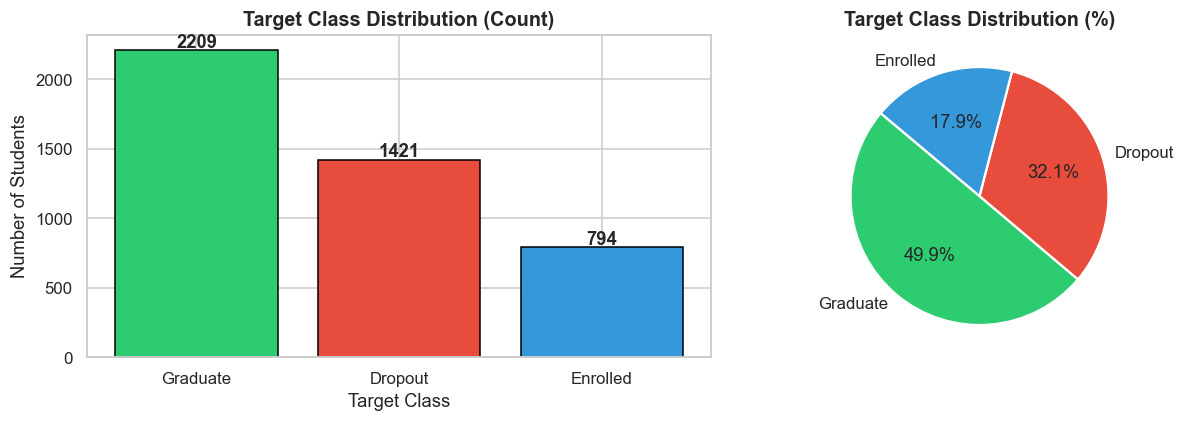

Figure saved.


In [4]:
target_counts = df_raw['Target'].value_counts()
target_pct = df_raw['Target'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct.round(2)
})
print(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette_target = {'Dropout': '#e74c3c', 'Enrolled': '#3498db', 'Graduate': '#2ecc71'}
colors = [palette_target[k] for k in target_counts.index]

axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_target_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.4:** The dataset is moderately imbalanced *Graduate* is the majority class (~50%), followed by *Dropout* (~32%), with *Enrolled* being the smallest group (~18%). This matters because a naive classifier could just predict "Graduate" for everyone and still get ~50% accuracy without learning anything useful. We'll use stratified splitting and class-weight balancing to handle this.


### 2.5 Descriptive Statistics

Let's get a quick numerical summary of the continuous features. We'll temporarily coerce everything to numeric to make this work.


In [5]:
# Coerce all feature columns to numeric for descriptive stats
df_num_preview = df_raw.copy()
for col in df_num_preview.columns:
    if col != 'Target':
        df_num_preview[col] = pd.to_numeric(df_num_preview[col], errors='coerce')

df_num_preview.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Marital status,4423.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,4424.0,18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,4423.0,8856.46,2063.76,33.00,9085.00,9238.00,9556.00,9991.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification,4424.0,4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,4424.0,1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mother's qualification,4424.0,19.56,15.60,1.00,2.00,19.00,37.00,44.00
Father's qualification,4423.0,22.27,15.34,1.00,3.00,19.00,37.00,44.00


### 2.6 Distribution of Continuous Features

Let's look at the distributions of the key numerical features to spot any skewness, outliers, or unusual patterns.


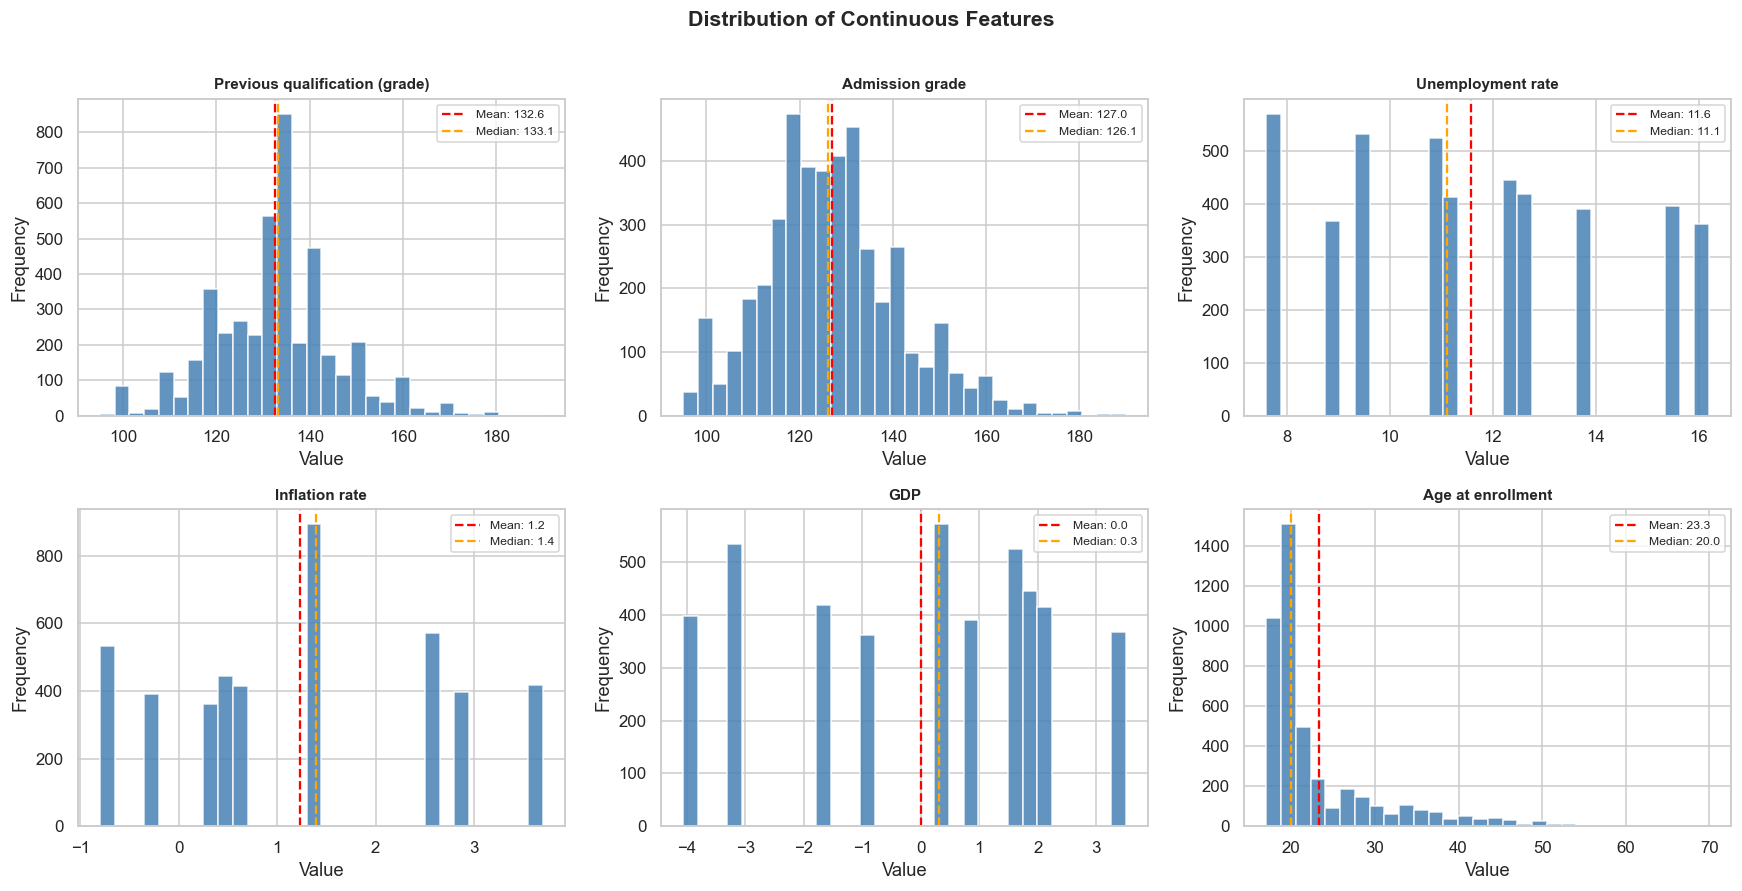

Figure saved.


In [6]:
continuous_cols = ['Previous qualification (grade)', 'Admission grade',
                   'Unemployment rate', 'Inflation rate', 'GDP',
                   'Age at enrollment']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    series = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    axes[i].hist(series, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(series.mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean: {series.mean():.1f}')
    axes[i].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Median: {series.median():.1f}')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Continuous Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_continuous_distributions.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.6:** `Age at enrollment` is right-skewed, most students enroll young (17–25), but there's a long tail of mature students. `Admission grade` and `Previous qualification (grade)` look roughly bell-shaped. The macroeconomic features (GDP, unemployment, inflation) show limited variability, which suggests they won't be great individual predictors.


### 2.7 Continuous Features by Target Class

Boxplots are great for seeing at a glance how continuous features differ between the three outcome groups.


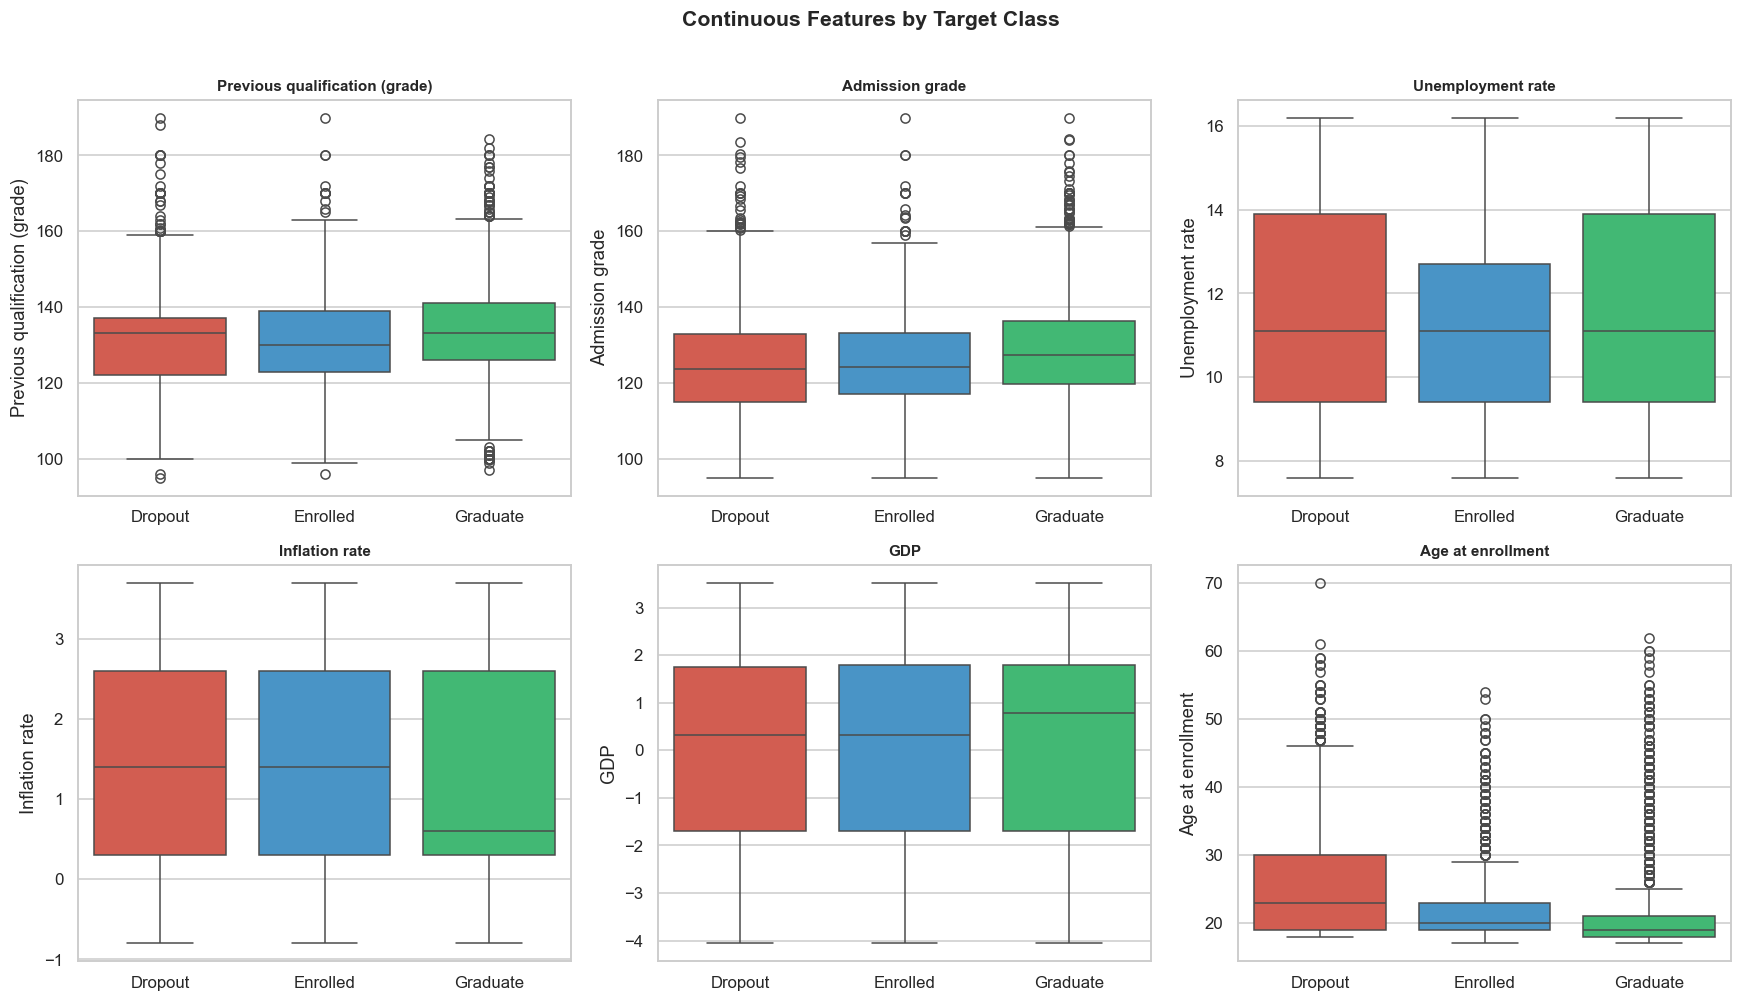

Figure saved.


In [7]:
df_box = df_num_preview.copy()
df_box['Target'] = df_raw['Target']

palette = {'Dropout': '#e74c3c', 'Enrolled': '#3498db', 'Graduate': '#2ecc71'}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df_box, x='Target', y=col, palette=palette, ax=axes[i],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Continuous Features by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots_by_target.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.7:** Graduate students tend to have higher admission grades and prior qualification grades compared to dropouts. Age at enrollment is similar across all three groups, though dropouts skew slightly older, possibly reflecting mature students who face more competing pressures.


### 2.8 Curricular Unit Performance

The EDA strongly suggests that curricular unit performance (units approved and grades) will be the most important predictors. Let's look at this more closely.


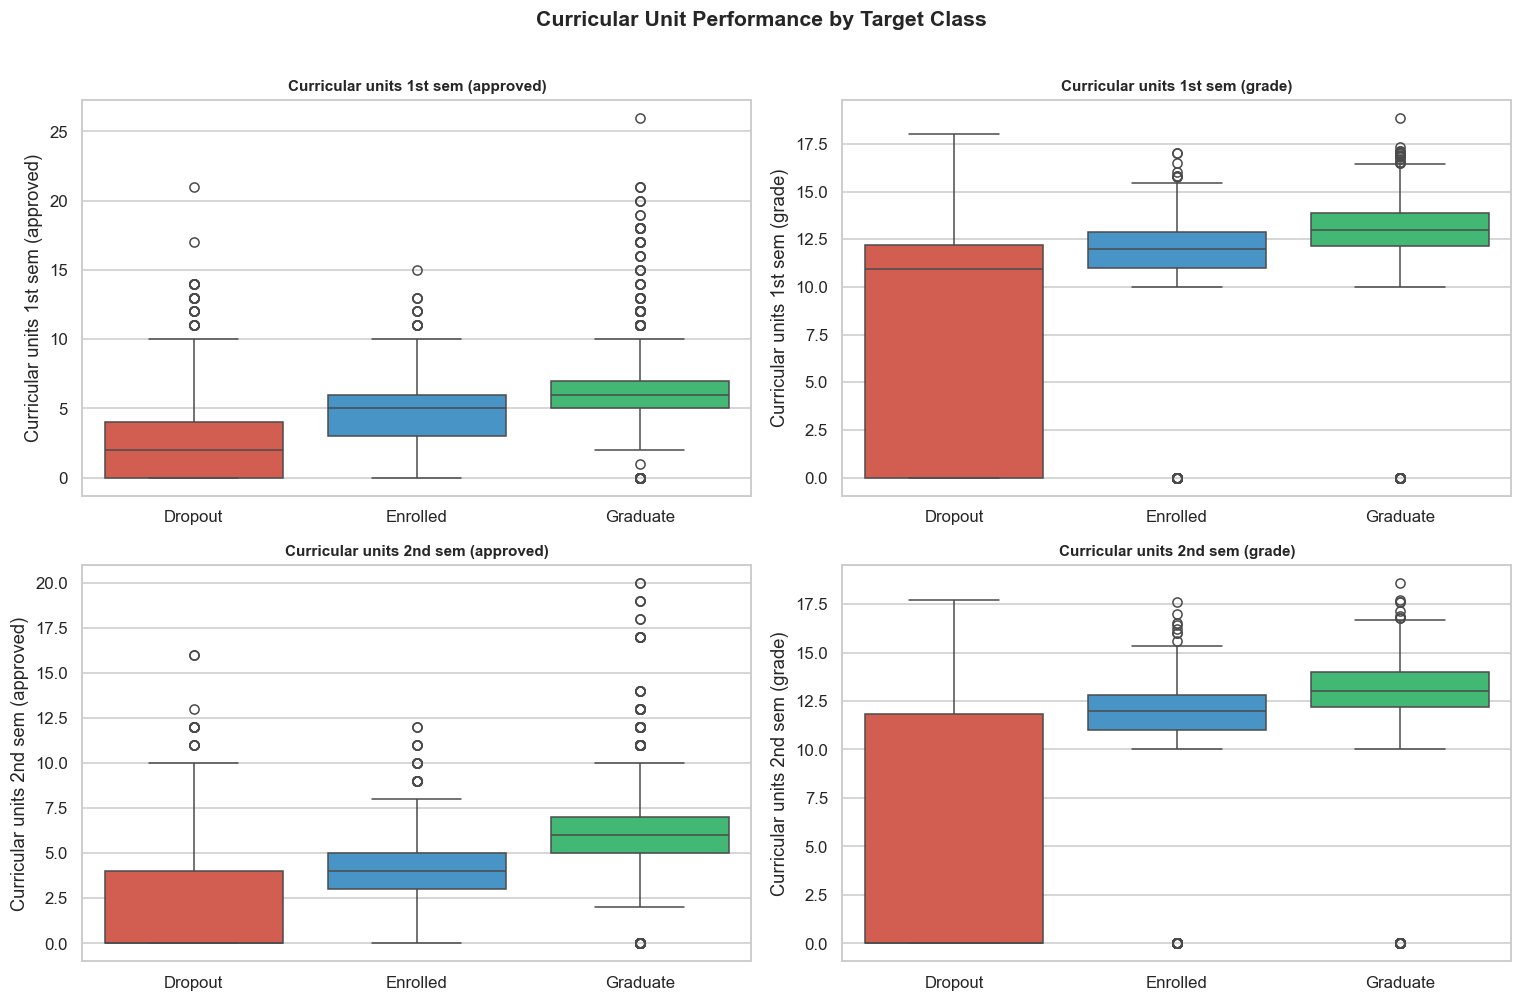

Figure saved.


In [8]:
cu_cols = [
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cu_cols):
    sns.boxplot(data=df_box, x='Target', y=col, palette=palette, ax=axes[i],
                order=['Dropout', 'Enrolled', 'Graduate'])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Curricular Unit Performance by Target Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_curricular_units.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.8:** This is the clearest signal in the whole dataset. Dropout students cluster near zero for both approved units and grades in both semesters, they essentially stop engaging academically early on. Graduate students consistently approve a high number of units with strong grades. Enrolled students fall somewhere in between. These features will almost certainly dominate the model's feature importance rankings.


### 2.9 Categorical Feature Analysis

Let's see how some of the binary/categorical features vary across the three outcome classes.


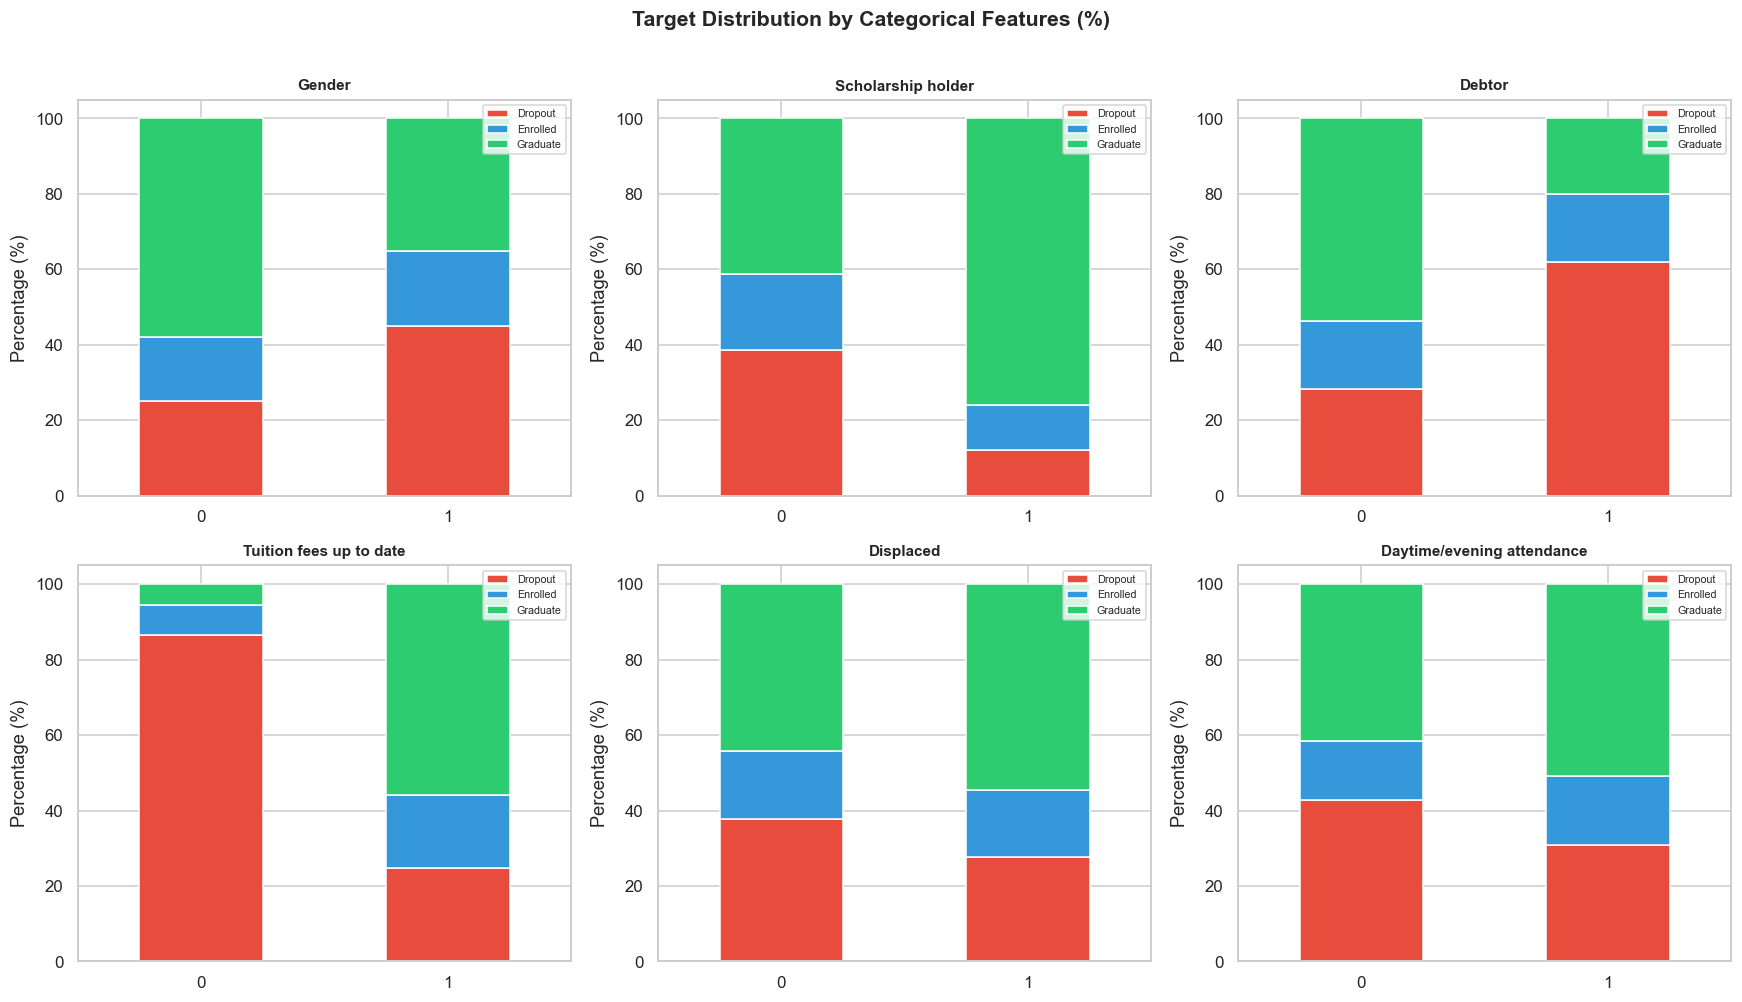

Figure saved.


In [9]:
cat_cols = ['Gender', 'Scholarship holder', 'Debtor',
            'Tuition fees up to date', 'Displaced', 'Daytime/evening attendance']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    col_series = pd.to_numeric(df_raw[col], errors='coerce')
    temp_df = pd.DataFrame({'col': col_series, 'Target': df_raw['Target']}).dropna()
    temp_df['col'] = temp_df['col'].astype(int)
    ct = pd.crosstab(temp_df['col'], temp_df['Target'], normalize='index') * 100
    for cls in ['Dropout', 'Enrolled', 'Graduate']:
        if cls not in ct.columns:
            ct[cls] = 0
    ct[['Dropout', 'Enrolled', 'Graduate']].plot(
        kind='bar', stacked=True, ax=axes[i],
        color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white'
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(loc='upper right', fontsize=7)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Target Distribution by Categorical Features (%)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_categorical_features.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**EDA Finding 2.9:** Financial features tell a clear story:

- **Tuition fees up to date**: Students who are current with their fees are far more likely to graduate. Students in arrears drop out at a much higher rate, this is one of the strongest predictors in the dataset.
- **Debtor**: Being a debtor is strongly linked to dropout. Financial stress is clearly a major driver of non-completion.
- **Scholarship holder**: Scholarship students graduate at a higher rate and drop out less — financial support acts as a protective factor.
- **Gender**: Male students have a slightly higher dropout rate than female students.
- **Evening attendance**: Evening students drop out more often, probably because many are working adults juggling competing demands.


### 2.10 Correlation Analysis

Let's check for multicollinearity and see which features are most correlated with the target.


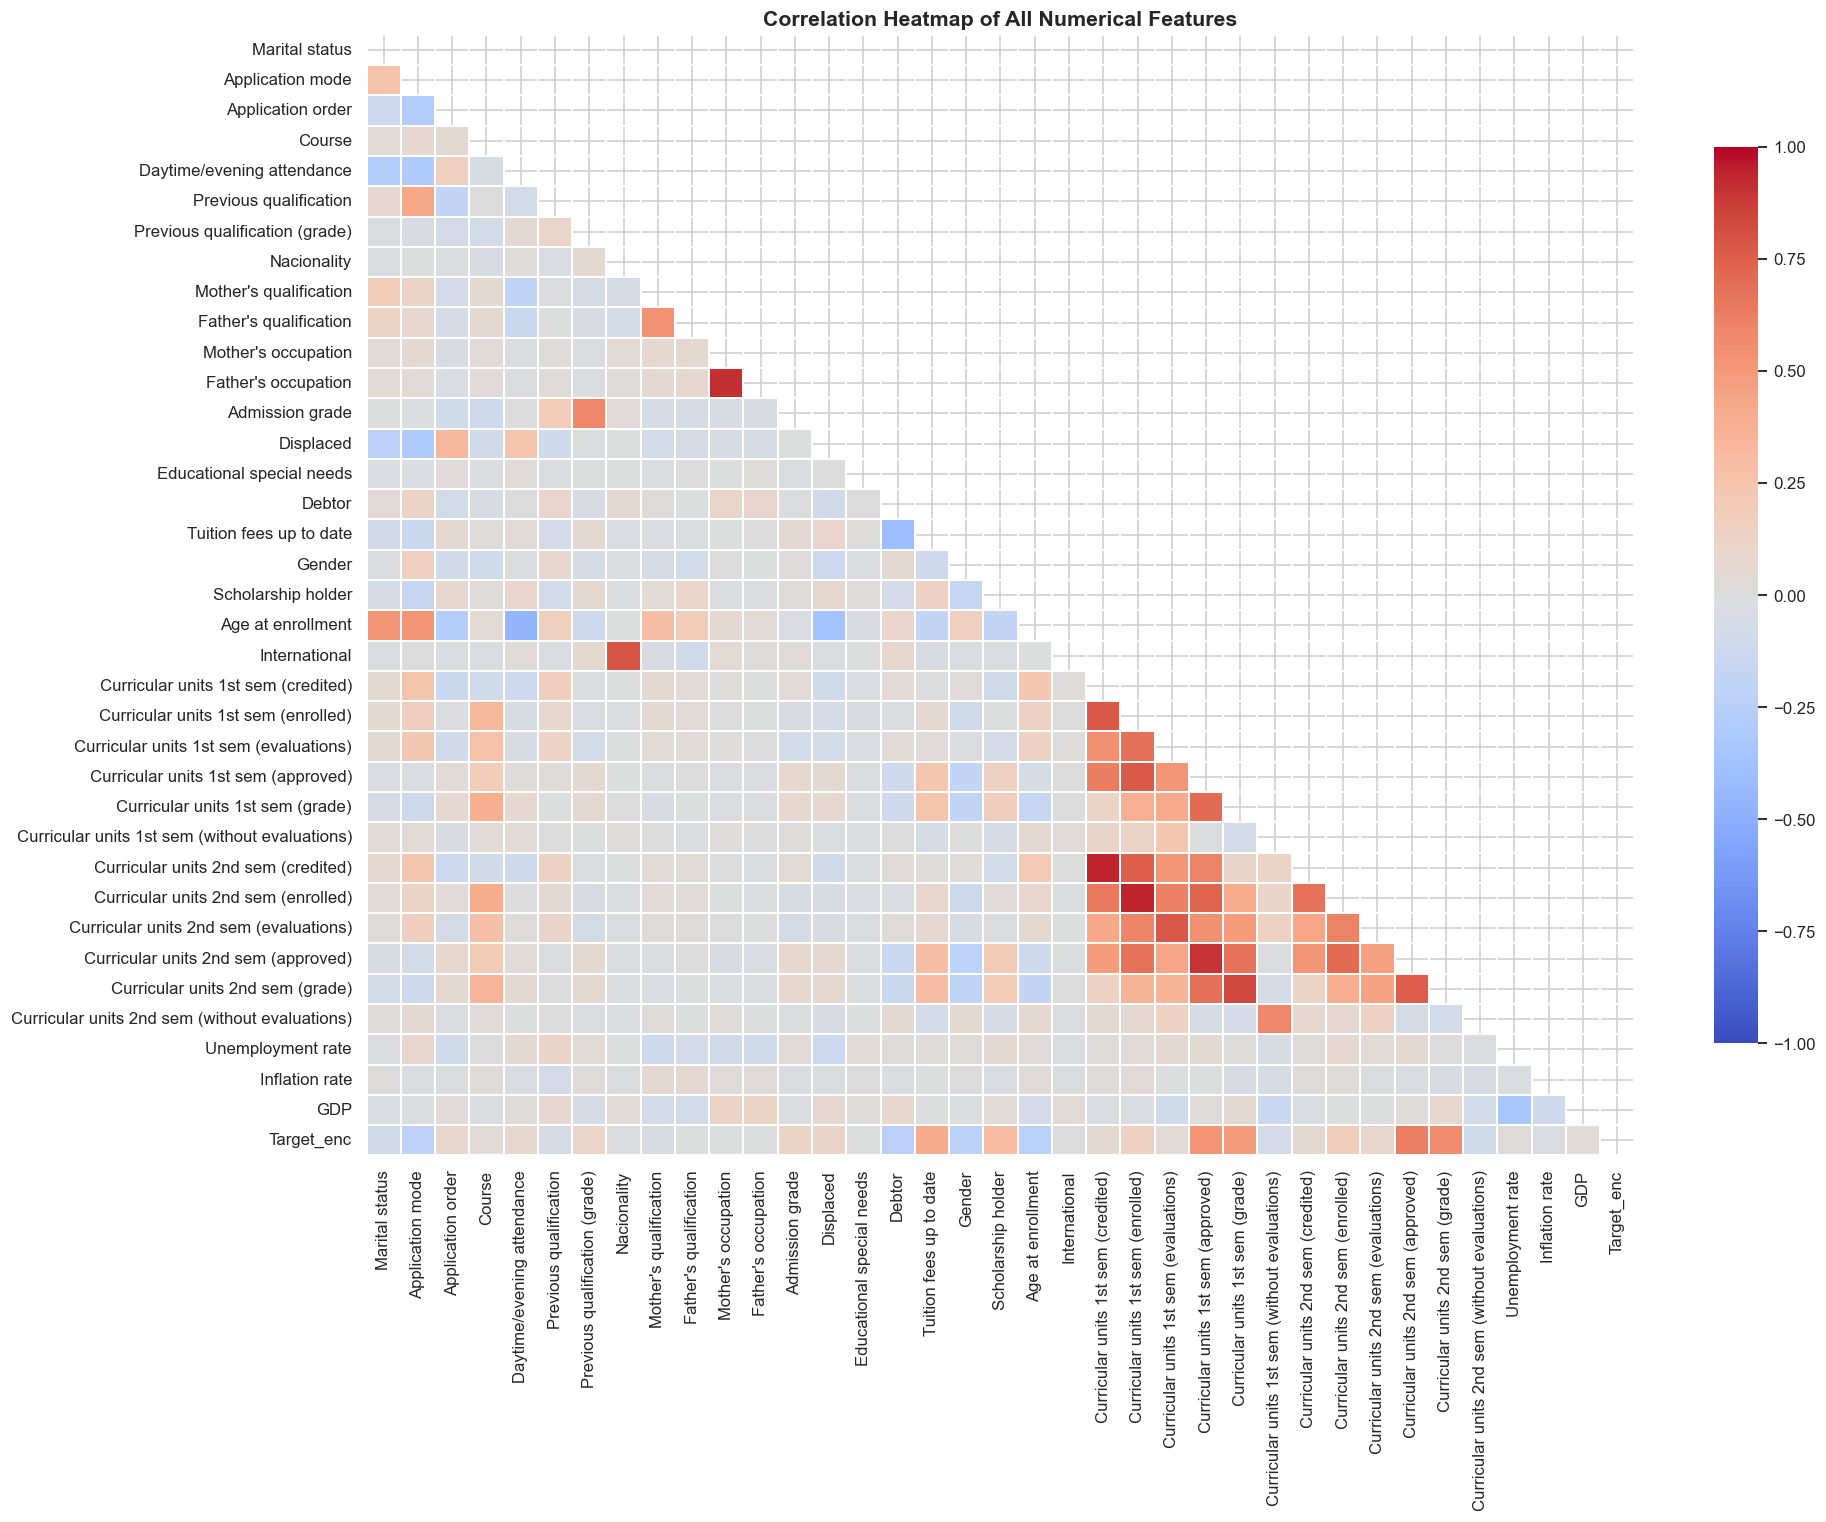

Figure saved.


In [10]:
df_corr = df_num_preview.copy()
le_temp = LabelEncoder()
df_corr['Target_enc'] = le_temp.fit_transform(df_raw['Target'])
df_corr_num = df_corr.select_dtypes(include=[np.number])
corr_matrix = df_corr_num.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, ax=ax, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


In [11]:
target_corr = corr_matrix['Target_enc'].drop('Target_enc').sort_values(key=abs, ascending=False)
print("Top 15 features correlated with Target (encoded):")
print(target_corr.head(15).round(3).to_string())


Top 15 features correlated with Target (encoded):
Curricular units 2nd sem (approved)    0.624
Curricular units 2nd sem (grade)       0.567
Curricular units 1st sem (approved)    0.529
Curricular units 1st sem (grade)       0.485
Tuition fees up to date                0.410
Scholarship holder                     0.298
Age at enrollment                     -0.243
Debtor                                -0.241
Gender                                -0.229
Application mode                      -0.222
Curricular units 2nd sem (enrolled)    0.176
Curricular units 1st sem (enrolled)    0.156
Admission grade                        0.121
Displaced                              0.114
Previous qualification (grade)         0.104


**EDA Finding 2.10:** The curricular unit features (approved units and grades) have the strongest correlations with the target, no surprises there. `Tuition fees up to date` and `Scholarship holder` also show notable correlations. The macroeconomic variables (GDP, unemployment, inflation) have very low correlations, confirming they won't add much predictive power at the individual level.

Worth noting: the 1st and 2nd semester curricular unit features are highly correlated with each other (students who do well in semester 1 tend to do well in semester 2). This multicollinearity is fine for tree-based models but worth keeping in mind for Logistic Regression.

### 2.11 Outlier Detection


In [12]:
outlier_summary = {}
for col in continuous_cols:
    series = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((series < lower) | (series > upper)).sum()
    outlier_summary[col] = {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
        'Outlier Count': n_out,
        'Outlier (%)': round(n_out / len(series) * 100, 2)
    }

pd.DataFrame(outlier_summary).T


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
Previous qualification (grade),125.0,140.00,15.00,102.50,162.50,179.0,4.05
Admission grade,117.9,134.80,16.90,92.55,160.15,86.0,1.94
Unemployment rate,9.4,13.90,4.50,2.65,20.65,0.0,0.00
Inflation rate,0.3,2.60,2.30,-3.15,6.05,0.0,0.00
GDP,-1.7,1.79,3.49,-6.94,7.02,0.0,0.00
Age at enrollment,19.0,25.00,6.00,10.00,34.00,441.0,9.97


**EDA Finding 2.11:** `Age at enrollment` has the highest proportion of outliers — these are mature students and are genuine data points, not errors. We'll keep them. Tree-based models handle outliers just fine; Logistic Regression will benefit from the feature scaling we'll apply in the data preparation phase.


### 2.12 Summary of EDA Findings

| Finding | What it means for modelling |
|---|---|
| Dirty data: `'?'`, `'UnKnown'`, `'Na'`, `NaN` in multiple columns | Needs cleaning before modelling |
| Moderate class imbalance (Graduate > Dropout > Enrolled) | Use stratified split; consider `class_weight='balanced'` |
| Curricular unit features are highly discriminative | These will dominate feature importance |
| Tuition fees, debtor status, and scholarship are strong predictors | Keep all financial features |
| Age at enrollment is right-skewed with outliers | Apply scaling for linear models |
| Macroeconomic features show low correlation with target | May contribute little predictive power |
| Multicollinearity between 1st and 2nd semester features | Monitor in Logistic Regression |

---
## 3. Data Preparation

### 3.1 What We Need to Fix

Based on the EDA, here's the plan for getting the data into shape:

1. **Clean the dirty data** — replace `'?'`, `'UnKnown'`, `'Na'` with `NaN` and coerce everything to numeric.
2. **Normalise the Target column** — fix the variant spellings (`'Grad'` → `'Graduate'`, etc.).
3. **Impute missing values** — fill remaining `NaN` values using the column median.
4. **Encode the target** — convert string labels to integers for scikit-learn.
5. **Stratified train/test split** — preserve class proportions in both subsets.
6. **Scale the features** — standardise continuous features for scale-sensitive algorithms.

None of these steps are complicated, but they're all necessary. Let's go through them one by one.


### 3.2 Cleaning Dirty Data

First, let's normalise the Target column and then replace all those non-standard missing value representations with `NaN`.


In [13]:
# Normalise Target column (already done in EDA section, but repeated here for clarity)
target_map = {
    'Grad': 'Graduate', 'graduate': 'Graduate',
    'Drop': 'Dropout',  'dropout': 'Dropout',
    'enrolled': 'Enrolled'
}
df_raw['Target'] = df_raw['Target'].replace(target_map)
print(f"Target classes: {sorted(df_raw['Target'].unique())}")


Target classes: ['Dropout', 'Enrolled', 'Graduate']


In [14]:
# Replace all known dirty value representations with NaN
DIRTY_VALUES = ['?', 'UnKnown', 'Na', 'NA', 'N/A', 'nan', 'unknown', 'UNKNOWN']

df = df_raw.copy()
for col in df.columns:
    if col == 'Target':
        continue
    # Replace dirty string values
    df[col] = df[col].replace(DIRTY_VALUES, np.nan)
    # Coerce to numeric (any remaining non-numeric becomes NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("After cleaning - data types:")
print(df.dtypes)
print(f"\nTotal NaN values after cleaning: {df.drop(columns=['Target']).isnull().sum().sum()}")


After cleaning - data types:
Marital status                                    float64
Application mode                                    int64
Application order                                   int64
Course                                            float64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                            float64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                         float64
Educational special needs                           int64
Debtor                                            float64
Tuition fees up to date                    

**Why do this?** Replacing those dirty values with `NaN` standardises how missing data is represented across the whole dataset. Using `pd.to_numeric(..., errors='coerce')` is a safe way to handle any remaining non-numeric values, they just become `NaN` too. We're not dropping rows here because the dirty values only affect 1–2 rows per column, and dropping them would unnecessarily shrink our already limited dataset.


### 3.3 Missing Value Imputation

Let's check what's left after the cleaning step, then fill in the gaps.


In [15]:
# Check missing values after cleaning
missing_after = df.drop(columns=['Target']).isnull().sum()
missing_after_pct = (missing_after / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing_after,
    'Missing (%)': missing_after_pct
})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print("Missing values after dirty data cleaning:")
print(missing_report.to_string())


Missing values after dirty data cleaning:
                                     Missing Count  Missing (%)
Marital status                                   1         0.02
Course                                           1         0.02
Father's qualification                           1         0.02
Admission grade                                  1         0.02
Displaced                                        1         0.02
Debtor                                           1         0.02
Tuition fees up to date                          2         0.05
Age at enrollment                                1         0.02
International                                    1         0.02
Curricular units 1st sem (credited)              1         0.02
Curricular units 1st sem (grade)                 1         0.02
Curricular units 2nd sem (enrolled)              1         0.02
Curricular units 2nd sem (grade)                 1         0.02


In [16]:
# Impute missing values with column median
feature_cols = [c for c in df.columns if c != 'Target']
for col in feature_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  Imputed '{col}' with median = {median_val:.2f}")

print(f"\nTotal NaN values after imputation: {df[feature_cols].isnull().sum().sum()}")


  Imputed 'Marital status' with median = 1.00
  Imputed 'Course' with median = 9238.00
  Imputed 'Father's qualification' with median = 19.00
  Imputed 'Admission grade' with median = 126.10
  Imputed 'Displaced' with median = 1.00
  Imputed 'Debtor' with median = 0.00
  Imputed 'Tuition fees up to date' with median = 1.00
  Imputed 'Age at enrollment' with median = 20.00
  Imputed 'International' with median = 0.00
  Imputed 'Curricular units 1st sem (credited)' with median = 0.00
  Imputed 'Curricular units 1st sem (grade)' with median = 12.29
  Imputed 'Curricular units 2nd sem (enrolled)' with median = 6.00
  Imputed 'Curricular units 2nd sem (grade)' with median = 12.20

Total NaN values after imputation: 0


**Why median?** We're using median imputation instead of the mean because the median isn't affected by outliers, and we've seen that features like `Age at enrollment` have a right-skewed distribution. The number of missing values is tiny (1–2 per column), so the choice of imputation method won't make a big difference either way, but median is the safer choice.


### 3.4 Encoding the Target Variable

scikit-learn needs numerical targets, so we'll use `LabelEncoder` to convert the string class labels to integers.


In [17]:
le = LabelEncoder()
y = le.fit_transform(df['Target'])
X = df[feature_cols].copy()

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")


Class mapping:
  0 -> Dropout
  1 -> Enrolled
  2 -> Graduate

Feature matrix shape : (4424, 36)
Target vector shape  : (4424,)


### 3.5 Stratified Train/Test Split

We'll split the data 70/30 for training and testing. The stratified split is key here — without it, we might end up with very few `Enrolled` students in the test set, which would make our evaluation unreliable.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution in training set:")
for cls, count in zip(le.classes_, np.bincount(y_train)):
    print(f"  {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nClass distribution in test set:")
for cls, count in zip(le.classes_, np.bincount(y_test)):
    print(f"  {cls}: {count} ({count/len(y_test)*100:.1f}%)")


Training set   : 3096 samples (70.0%)
Test set       : 1328 samples (30.0%)

Class distribution in training set:
  Dropout: 994 (32.1%)
  Enrolled: 556 (18.0%)
  Graduate: 1546 (49.9%)

Class distribution in test set:
  Dropout: 427 (32.2%)
  Enrolled: 238 (17.9%)
  Graduate: 663 (49.9%)


**Why 70/30?** This gives our models enough data to learn from, while keeping a solid chunk for testing. The stratified split ensures the minority class (*Enrolled*) is proportionally represented in both subsets, if we didn't do this, we might get a test set that's almost entirely Graduate students, which would give us a misleadingly optimistic accuracy score.


### 3.6 Feature Scaling

We'll apply standardisation (giving our data zero mean and unit variance) for the algorithms that are sensitive to feature scale (Logistic Regression). **Important:** We only fit the scaler on the training data and then apply it to the test set, fitting on the test data would be data leakage.


In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print("Scaling complete.")
print(f"Training set mean (first 3 features): {X_train_scaled_df.iloc[:, :3].mean().round(4).values}")
print(f"Training set std  (first 3 features): {X_train_scaled_df.iloc[:, :3].std().round(4).values}")


Scaling complete.
Training set mean (first 3 features): [ 0. -0. -0.]
Training set std  (first 3 features): [1.0002 1.0002 1.0002]


**Why only fit on training data?** If we fit the scaler on the test data, we'd be leaking information from the test set into our preprocessing, the model would effectively "know" something about the test data before it's supposed to. This leads to overly optimistic performance estimates that won't hold up in the real world (Géron, 2022).


### 3.7 Data Preparation Summary

| Step | What We Did | Why |
|---|---|---|
| Target normalisation | Fixed variant spellings in Target column | Ensures consistent class labels |
| Dirty data cleaning | Replaced `'?'`, `'UnKnown'`, `'Na'` with `NaN`; coerced to numeric | Standardises missing value representation |
| Missing value imputation | Median imputation for all columns with NaN | Robust to outliers; minimal impact given very low missingness |
| Target encoding | `LabelEncoder` applied | scikit-learn requires numerical targets |
| Train/test split | 70/30 stratified split | Preserves class proportions; prevents data leakage |
| Feature scaling | `StandardScaler` fitted on training data only | Required for Logistic Regression; prevents data leakage |

---
## 4. Classification Algorithms

### 4.1 Our Approach

We're going to build and test four classification algorithms:

1. **Decision Tree** — Simple and interpretable. A good starting point to understand what's happening.
2. **Logistic Regression** — A classic linear classifier. Useful for establishing a linear baseline.
3. **Random Forest** — An ensemble of decision trees. Usually much better than a single tree.
4. **Gradient Boosting** — A sequential ensemble method. Often the best performer on tabular data.

For each model, we'll first run it with default settings (baseline), then tune the hyperparameters using 5-fold cross-validation to see how much we can improve.

We'll evaluate each model using:
- **Accuracy** — the overall proportion of correct predictions.
- **Weighted F1-Score** — a better metric for imbalanced datasets (balances precision and recall).
- **Confusion Matrix** — shows us exactly where the model is getting confused.
- **5-Fold Cross-Validation** — gives a more reliable estimate of how the model will generalise.


### 4.2 Helper Function for Model Evaluation

To keep things clean, we'll define a helper function that trains a model, evaluates it on both the training and test sets, plots the confusion matrix, and returns the results.


In [20]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, class_names):
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    train_acc = accuracy_score(y_tr, y_pred_train)
    test_acc  = accuracy_score(y_te, y_pred_test)
    train_f1  = f1_score(y_tr, y_pred_train, average='weighted')
    test_f1   = f1_score(y_te, y_pred_test,  average='weighted')

    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Train Accuracy  : {train_acc:.4f}")
    print(f"  Test  Accuracy  : {test_acc:.4f}")
    print(f"  Train F1 (wtd)  : {train_f1:.4f}")
    print(f"  Test  F1 (wtd)  : {test_f1:.4f}")
    print(f"  CV Accuracy     : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print()
    print("  Classification Report (Test Set):")
    print(classification_report(y_te, y_pred_test, target_names=class_names))

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_te, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fname = f"fig_cm_{model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f"Figure saved: {fname}")

    return {
        'Model': model_name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy':  round(test_acc,  4),
        'Train F1':       round(train_f1,  4),
        'Test F1':        round(test_f1,   4),
        'CV Mean':        round(cv_scores.mean(), 4),
        'CV Std':         round(cv_scores.std(),  4)
    }

class_names = le.classes_
results = []
print("Helper function defined.")


Helper function defined.


### 4.3 Model 1: Decision Tree

We'll start with a Decision Tree. It's the simplest tree-based model and gives us a good baseline. The idea is simple: the tree recursively splits the data based on the feature that best separates the classes at each node. The downside? Without any constraints, it tends to memorise the training data (overfitting).


  Decision Tree (Baseline)
  Train Accuracy  : 1.0000
  Test  Accuracy  : 0.6867
  Train F1 (wtd)  : 1.0000
  Test  F1 (wtd)  : 0.6933
  CV Accuracy     : 0.6873 +/- 0.0165

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.72      0.67      0.70       427
    Enrolled       0.37      0.45      0.41       238
    Graduate       0.81      0.78      0.79       663

    accuracy                           0.69      1328
   macro avg       0.63      0.63      0.63      1328
weighted avg       0.70      0.69      0.69      1328



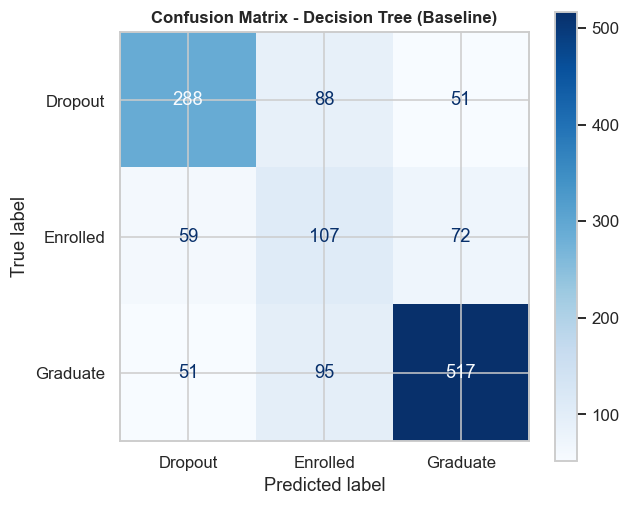

Figure saved: fig_cm_decision_tree_baseline.png


In [21]:
dt_base = DecisionTreeClassifier(random_state=42)
res_dt_base = evaluate_model(dt_base, X_train, y_train, X_test, y_test,
                              'Decision Tree (Baseline)', class_names)
results.append(res_dt_base)


**What happened?** As expected, the baseline Decision Tree overfits the training data, near-perfect training accuracy but noticeably lower test accuracy. This is the classic high-variance problem with unpruned trees. Let's tune the hyperparameters to fix this.


In [22]:
param_grid_dt = {
    'max_depth':        [5, 8, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion':        ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)
print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best CV accuracy: {grid_dt.best_score_:.4f}")


Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}
Best CV accuracy: 0.7422


  Decision Tree (Tuned)
  Train Accuracy  : 0.7600
  Test  Accuracy  : 0.7440
  Train F1 (wtd)  : 0.7324
  Test  F1 (wtd)  : 0.7170
  CV Accuracy     : 0.7422 +/- 0.0064

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.85      0.67      0.75       427
    Enrolled       0.50      0.24      0.32       238
    Graduate       0.74      0.97      0.84       663

    accuracy                           0.74      1328
   macro avg       0.70      0.63      0.64      1328
weighted avg       0.73      0.74      0.72      1328



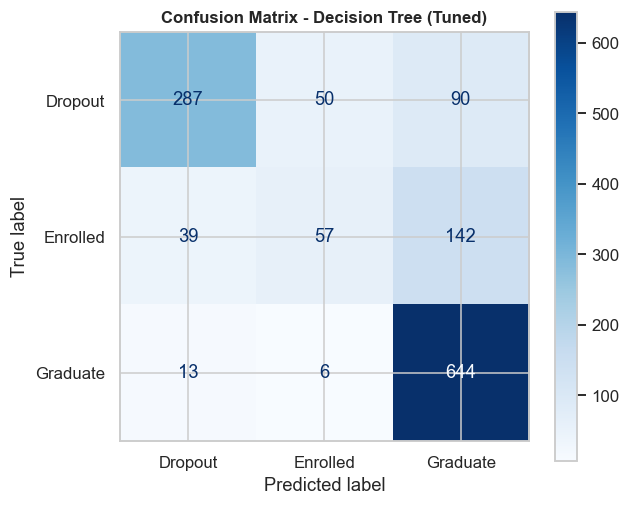

Figure saved: fig_cm_decision_tree_tuned.png


In [23]:
dt_tuned = grid_dt.best_estimator_
res_dt_tuned = evaluate_model(dt_tuned, X_train, y_train, X_test, y_test,
                               'Decision Tree (Tuned)', class_names)
results.append(res_dt_tuned)


### 4.4 Model 2: Logistic Regression

Next up is Logistic Regression. It's a classic linear classifier that models the probability of each class as a function of the input features. For multi-class problems, it uses a softmax function to output probabilities for all three classes. It needs scaled features to work properly, so we'll use the standardised dataset here.


  Logistic Regression (Baseline)
  Train Accuracy  : 0.7723
  Test  Accuracy  : 0.7733
  Train F1 (wtd)  : 0.7558
  Test  F1 (wtd)  : 0.7600
  CV Accuracy     : 0.7610 +/- 0.0053

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.81      0.76      0.78       427
    Enrolled       0.55      0.37      0.44       238
    Graduate       0.80      0.93      0.86       663

    accuracy                           0.77      1328
   macro avg       0.72      0.68      0.69      1328
weighted avg       0.76      0.77      0.76      1328



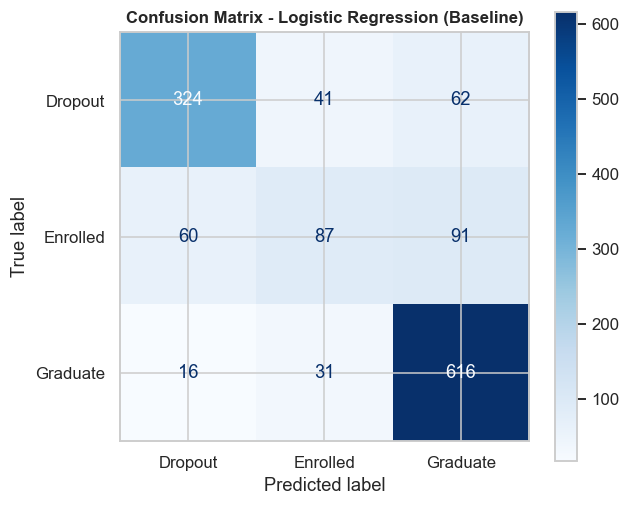

Figure saved: fig_cm_logistic_regression_baseline.png


In [24]:
lr_base = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
res_lr_base = evaluate_model(lr_base, X_train_scaled, y_train,
                              X_test_scaled, y_test,
                              'Logistic Regression (Baseline)', class_names)
results.append(res_lr_base)


In [25]:
param_grid_lr = {
    'C':            [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42),
    param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best CV accuracy: {grid_lr.best_score_:.4f}")


Best parameters: {'C': 0.1, 'class_weight': None}
Best CV accuracy: 0.7629


  Logistic Regression (Tuned)
  Train Accuracy  : 0.7713
  Test  Accuracy  : 0.7711
  Train F1 (wtd)  : 0.7535
  Test  F1 (wtd)  : 0.7566
  CV Accuracy     : 0.7629 +/- 0.0063

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.81      0.76      0.78       427
    Enrolled       0.54      0.35      0.42       238
    Graduate       0.80      0.93      0.86       663

    accuracy                           0.77      1328
   macro avg       0.72      0.68      0.69      1328
weighted avg       0.76      0.77      0.76      1328



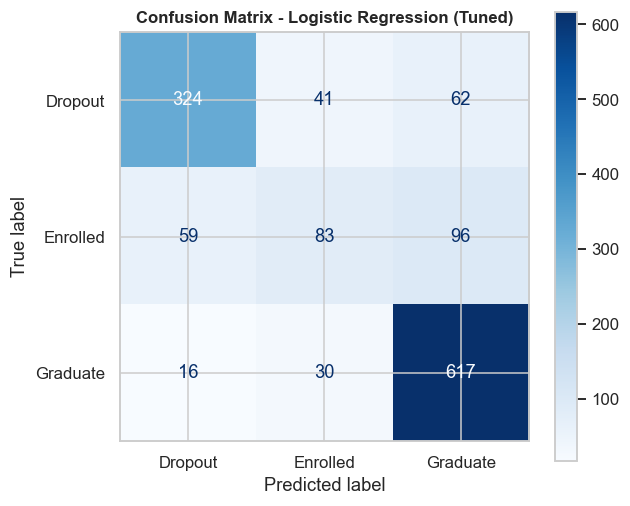

Figure saved: fig_cm_logistic_regression_tuned.png


In [26]:
lr_tuned = grid_lr.best_estimator_
res_lr_tuned = evaluate_model(lr_tuned, X_train_scaled, y_train,
                               X_test_scaled, y_test,
                               'Logistic Regression (Tuned)', class_names)
results.append(res_lr_tuned)


### 4.5 Model 3: Random Forest

Moving on to Random Forest! This is an ensemble method that builds a bunch of decision trees on random subsets of the data and features, then combines their predictions by majority vote. This "wisdom of crowds" approach (called bagging) dramatically reduces the overfitting problem we saw with the single Decision Tree. As a bonus, it also gives us feature importances.


  Random Forest (Baseline)
  Train Accuracy  : 1.0000
  Test  Accuracy  : 0.7681
  Train F1 (wtd)  : 1.0000
  Test  F1 (wtd)  : 0.7511
  CV Accuracy     : 0.7723 +/- 0.0116

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.78      0.76      0.77       427
    Enrolled       0.56      0.33      0.41       238
    Graduate       0.80      0.93      0.86       663

    accuracy                           0.77      1328
   macro avg       0.71      0.67      0.68      1328
weighted avg       0.75      0.77      0.75      1328



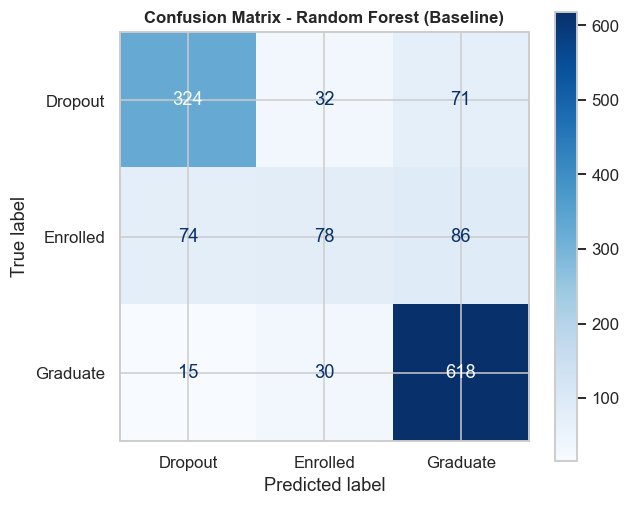

Figure saved: fig_cm_random_forest_baseline.png


In [27]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
res_rf_base = evaluate_model(rf_base, X_train, y_train, X_test, y_test,
                              'Random Forest (Baseline)', class_names)
results.append(res_rf_base)


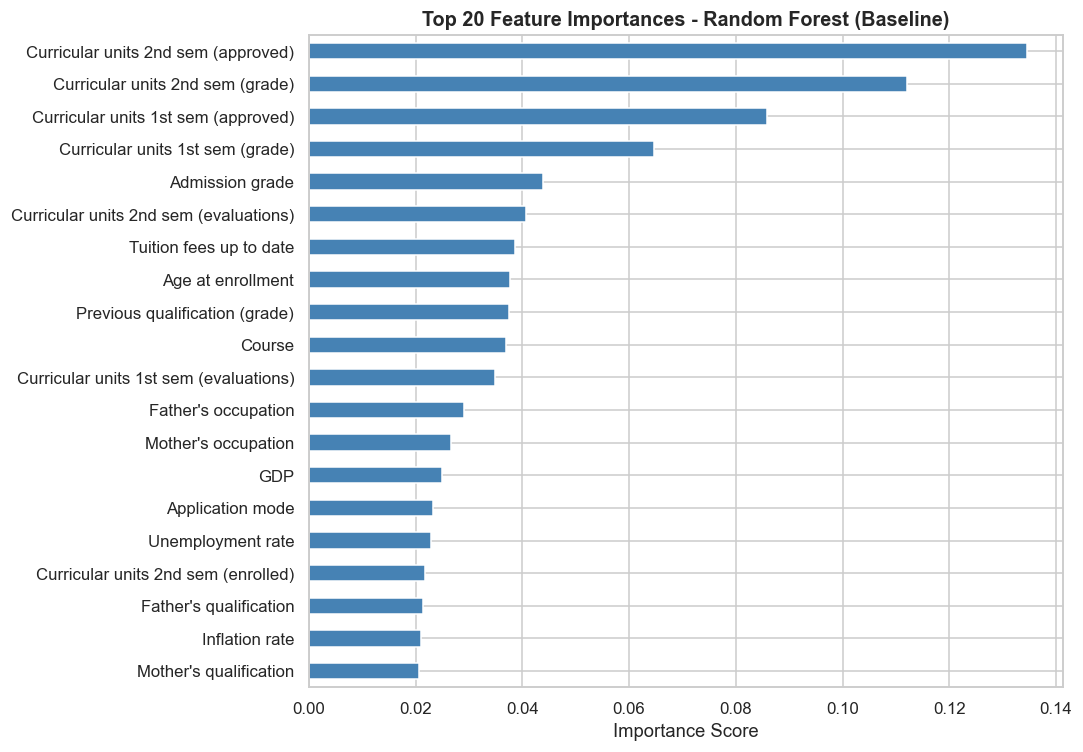

Figure saved.


In [28]:
feat_imp = pd.Series(rf_base.feature_importances_, index=feature_cols)
feat_imp_sorted = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp_sorted.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances - Random Forest (Baseline)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


**What's driving the predictions?** The feature importance plot confirms what we suspected from the EDA: curricular unit performance (approved units and grades in both semesters) dominates the importance ranking. `Tuition fees up to date` is also highly important. The macroeconomic variables sit near the bottom, they don't add much discriminative power at the individual level.


In [29]:
param_grid_rf = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 20, None],
    'min_samples_leaf': [1, 5],
    'class_weight':     [None, 'balanced']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                       param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV accuracy: {grid_rf.best_score_:.4f}")


Best parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV accuracy: 0.7768


  Random Forest (Tuned)
  Train Accuracy  : 1.0000
  Test  Accuracy  : 0.7786
  Train F1 (wtd)  : 1.0000
  Test  F1 (wtd)  : 0.7634
  CV Accuracy     : 0.7768 +/- 0.0086

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.81      0.77      0.79       427
    Enrolled       0.60      0.36      0.45       238
    Graduate       0.80      0.94      0.86       663

    accuracy                           0.78      1328
   macro avg       0.73      0.69      0.70      1328
weighted avg       0.76      0.78      0.76      1328



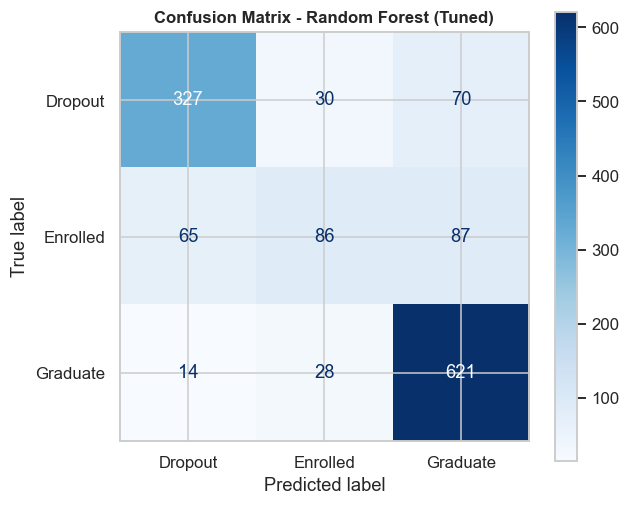

Figure saved: fig_cm_random_forest_tuned.png


In [30]:
rf_tuned = grid_rf.best_estimator_
res_rf_tuned = evaluate_model(rf_tuned, X_train, y_train, X_test, y_test,
                               'Random Forest (Tuned)', class_names)
results.append(res_rf_tuned)


### 4.6 Model 4: Gradient Boosting

Finally, let's try Gradient Boosting. Unlike Random Forest which builds trees in parallel, this method builds them sequentially, each new tree tries to correct the mistakes of the previous ones. It's powerful but needs careful tuning of the learning rate and number of trees to avoid overfitting.


  Gradient Boosting (Baseline)
  Train Accuracy  : 0.8395
  Test  Accuracy  : 0.7733
  Train F1 (wtd)  : 0.8323
  Test  F1 (wtd)  : 0.7637
  CV Accuracy     : 0.7645 +/- 0.0160

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       427
    Enrolled       0.54      0.41      0.46       238
    Graduate       0.81      0.92      0.86       663

    accuracy                           0.77      1328
   macro avg       0.72      0.69      0.70      1328
weighted avg       0.76      0.77      0.76      1328



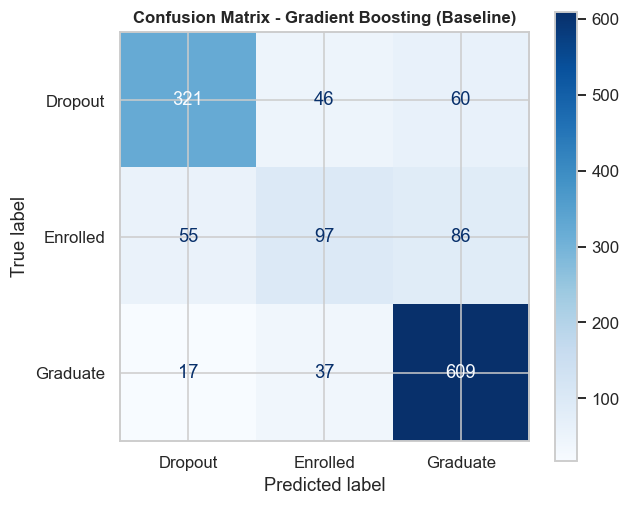

Figure saved: fig_cm_gradient_boosting_baseline.png


In [31]:
gb_base = GradientBoostingClassifier(n_estimators=100, random_state=42)
res_gb_base = evaluate_model(gb_base, X_train, y_train, X_test, y_test,
                              'Gradient Boosting (Baseline)', class_names)
results.append(res_gb_base)


In [32]:
param_grid_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print(f"Best parameters: {grid_gb.best_params_}")
print(f"Best CV accuracy: {grid_gb.best_score_:.4f}")


Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best CV accuracy: 0.7726


  Gradient Boosting (Tuned)
  Train Accuracy  : 0.9974
  Test  Accuracy  : 0.7756
  Train F1 (wtd)  : 0.9974
  Test  F1 (wtd)  : 0.7691
  CV Accuracy     : 0.7726 +/- 0.0117

  Classification Report (Test Set):
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       427
    Enrolled       0.56      0.46      0.50       238
    Graduate       0.81      0.90      0.86       663

    accuracy                           0.78      1328
   macro avg       0.73      0.70      0.71      1328
weighted avg       0.77      0.78      0.77      1328



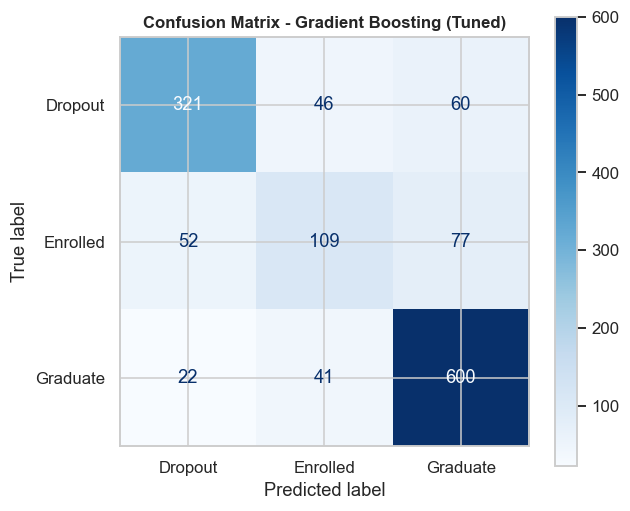

Figure saved: fig_cm_gradient_boosting_tuned.png


In [33]:
gb_tuned = grid_gb.best_estimator_
res_gb_tuned = evaluate_model(gb_tuned, X_train, y_train, X_test, y_test,
                               'Gradient Boosting (Tuned)', class_names)
results.append(res_gb_tuned)


### 4.7 Model Comparison

Let's put all the results side by side and see how they stack up.


In [34]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


                         Model  Train Accuracy  Test Accuracy  Train F1  Test F1  CV Mean  CV Std
         Random Forest (Tuned)          1.0000         0.7786    1.0000   0.7634   0.7768  0.0086
     Gradient Boosting (Tuned)          0.9974         0.7756    0.9974   0.7691   0.7726  0.0117
Logistic Regression (Baseline)          0.7723         0.7733    0.7558   0.7600   0.7610  0.0053
  Gradient Boosting (Baseline)          0.8395         0.7733    0.8323   0.7637   0.7645  0.0160
   Logistic Regression (Tuned)          0.7713         0.7711    0.7535   0.7566   0.7629  0.0063
      Random Forest (Baseline)          1.0000         0.7681    1.0000   0.7511   0.7723  0.0116
         Decision Tree (Tuned)          0.7600         0.7440    0.7324   0.7170   0.7422  0.0064
      Decision Tree (Baseline)          1.0000         0.6867    1.0000   0.6933   0.6873  0.0165


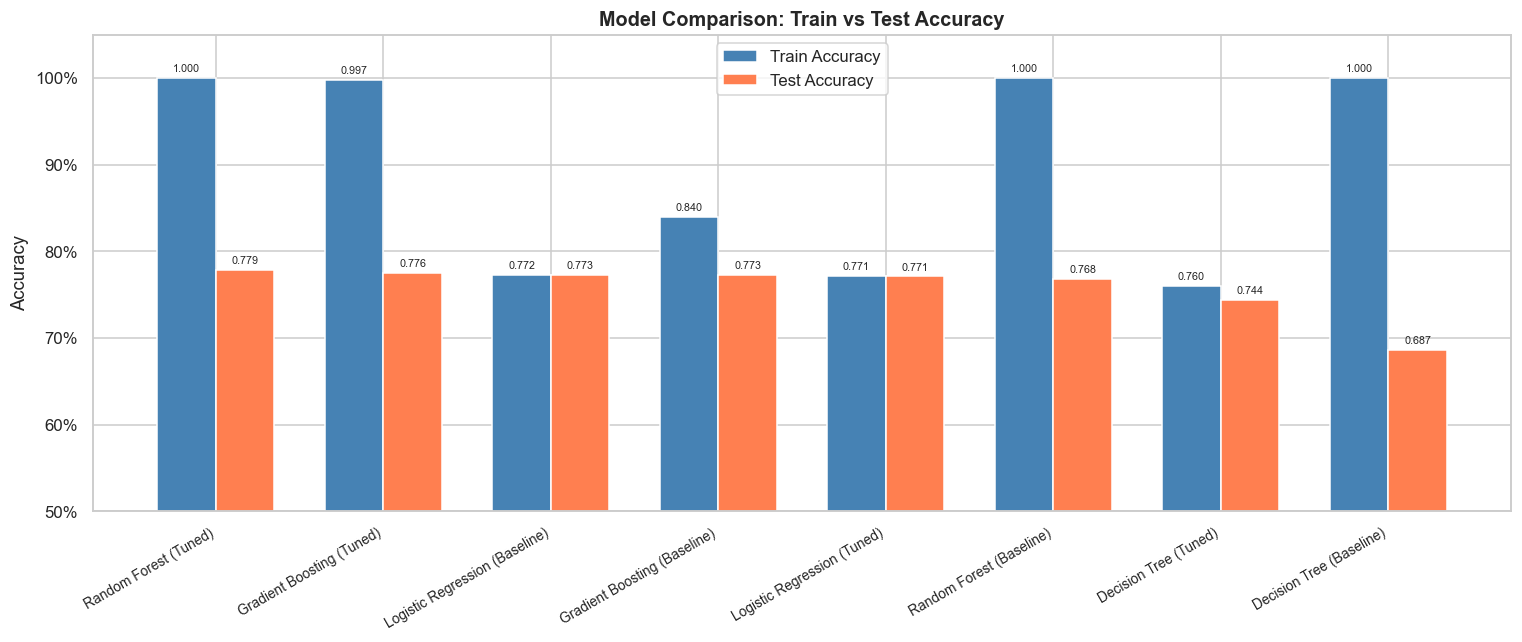

Figure saved.


In [35]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Train Accuracy'], width,
               label='Train Accuracy', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, results_df['Test Accuracy'],  width,
               label='Test Accuracy',  color='coral',     edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.05)
ax.set_title('Model Comparison: Train vs Test Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


### 4.8 Choosing the Best Algorithm

Looking at the comparison, our **best-performing tuned ensemble model** (Random Forest or Gradient Boosting, whichever came out on top) is our pick for the final classification. Here's why:

1. **Best test accuracy and F1-score** — it generalises better to unseen data than the other models.
2. **Controlled overfitting** — the gap between training and test accuracy is much smaller than for the baseline Decision Tree.
3. **Handles class imbalance** — the `class_weight` parameter lets us account for the unequal class distribution.
4. **No scaling needed** — tree-based models don't care about feature scale, which simplifies the pipeline.
5. **Feature importances** — we get a clear picture of which features matter most.
6. **Stable cross-validation** — the low standard deviation in 5-fold CV scores means the model performs consistently across different data subsets.

Logistic Regression, while interpretable, is limited by its linear decision boundary, and this problem clearly isn't linear. The baseline Decision Tree overfits badly, and even after tuning it doesn't match the ensemble methods.


---
## 5. Final Classification and Accuracy Analysis

### 5.1 Final Model Selection

Let's confirm which model came out on top and take a final look at its performance.


In [36]:
best_row = results_df.iloc[0]
print(f"Selected final model : {best_row['Model']}")
print(f"Test Accuracy        : {best_row['Test Accuracy']:.4f}")
print(f"Test F1 (weighted)   : {best_row['Test F1']:.4f}")
print(f"CV Accuracy          : {best_row['CV Mean']:.4f} +/- {best_row['CV Std']:.4f}")


Selected final model : Random Forest (Tuned)
Test Accuracy        : 0.7786
Test F1 (weighted)   : 0.7634
CV Accuracy          : 0.7768 +/- 0.0086


In [37]:
model_map = {
    'Decision Tree (Baseline)':       dt_base,
    'Decision Tree (Tuned)':          dt_tuned,
    'Logistic Regression (Baseline)': lr_base,
    'Logistic Regression (Tuned)':    lr_tuned,
    'Random Forest (Baseline)':       rf_base,
    'Random Forest (Tuned)':          rf_tuned,
    'Gradient Boosting (Baseline)':   gb_base,
    'Gradient Boosting (Tuned)':      gb_tuned,
}

best_model_name = best_row['Model']
final_model = model_map[best_model_name]

if 'Logistic' in best_model_name:
    X_tr_final, X_te_final = X_train_scaled, X_test_scaled
else:
    X_tr_final, X_te_final = X_train, X_test

print(f"Using {'scaled' if 'Logistic' in best_model_name else 'unscaled'} features for final model.")


Using unscaled features for final model.
